# Progetto Architetture Dati: Impatto della Data Quality sui Modelli di Machine Learning
---
---

## 1. Obiettivo del Progetto di Architetture Dati

In ambito aziendale e nelle moderne architetture dati, raramente i modelli di Machine Learning in produzione vengono alimentati con dati perfetti. Sensori malfunzionanti, errori di join, bug nelle API o inserimenti manuali errati sporcano costantemente il flusso informativo.

L'obiettivo di questo progetto è **certificare la robustezza della nostra Rete Neurale** misurando empiricamente e statisticamente il degrado delle sue performance al variare della Data Quality. Il lavoro si articola nei seguenti 5 step:
### **1.1 Step Operativi**
Il lavoro è stato suddiviso in 5 fasi logiche:
1. **Preparazione e Baseline Analysis:** Isolamento della MLP, calcolo delle metriche su dati puliti e calcolo del payload di metriche avanzate per stabilire il benchmark di riferimento
2. **Architettura del Degrado e Profilazione:** Studio di *Noise Injectors* per simulare errori nel database secondo le dimensioni di Data Quality
3. **Sperimentazione:** Sviluppo ed esecuzione degli stress, degradando progressivamente i dati di input come analizzato teoricamente nel capitolo precedente.
4. **Analisi Correlativa e Visualizzazione:** Studio della relazione tra metriche di qualità e calo della *Test Accuracy*.
5. **Risultati grafici**: grafici e commenti.
5. **Conclusioni Finali:** Valutazione della tolleranza ai guasti del modello.

### **1.2 Architettura del Repository**
Il progetto è strutturato come segue:

```text
Architetture-Dati-Progetto/
├── data/
│   ├── clean/
│   │   └── dataset_ml_ready.csv                # Dataset originale pulito (Baseline)
│   └── dirty/
│       └── dataset_*.csv                       # Dataset corrotti generati per ogni step di degrado 
│
├── docs/
│   ├── Architetture-Dati report.ipynb          # Report e relazione finale del progetto
│   ├── Presentazione tennis-prediction.pptx    # Presentazione progetto originale
│   └── tennis-prediction reporti.ipynb         # Report progetto originale
│ 
├── results/
│   ├── risultati_*.json                        # Cache delle metriche per ogni esperimento
│   └── plots/
│       └── *.png / *.jpg                       # Dashboard e grafici generati automaticamente 
│
├── src/
│   ├── baseline_data_quality.py                # Motore MLP, setup dello split temporale e salvataggio Baseline
│   ├── coerenza.py / plot_coerenza.py          # Script per gli esperimenti di Coerenza
│   ├── accuratezza.py / plot_accuratezza.py    # Script per gli esperimenti di Accuratezza
│   ├── completezza.py / plot_completezza.py    # Script per gli esperimenti di Completezza/Tempestività
│   └── pydeequ_compare.py                      # Data Profiling per scansionare i dataset in data/dirty/
│
├── requirements.txt                            # Dipendenze Python
└── README.md                                   # Documentazione tecnica per l'esecuzione del progetto


---
---

## 2. Introduzione e Background: ATP Tennis Prediction

Il punto di partenza di questo elaborato è un progetto di Machine Learning precedentemente sviluppato, finalizzato alla previsione dell'esito dei match di tennis ATP dal 2000 al 2024. 

Nel progetto originale, abbiamo costruito una complessa pipeline di Data Preparation per estrarre e calcolare oltre 30 feature storiche e prestazionali per ogni giocatore. Tra le metriche più importanti figurano:
- **Differenziale ELO** globale e per superficie.
- **Forma Recente** misurata in percentuale di vittorie nelle ultime 5, 25 e 50 partite.
- **Metriche di Efficienza** rappresentate dalla percentuale di prime di servizio vincenti, palle break salvate.
- **Fattori Fisici** come età, altezza, mano dominante.

Il modello definitivo scelto è stato una **Rete Neurale Multilayer Perceptron** con architettura `(128, 128, 64, 32)` e regolarizzazione `alpha=0.01`. Addestrata sui dati scalati dal 2000 al 2022, la rete ha raggiunto un'accuratezza solida e stabile (tra il 65% e il 71% a seconda delle configurazioni) sul Test Set comprendente tutte le partite degli anni 2023 e 2024. Infine è stata fatta una validazione finale calcolando l'accuracy del nostro modello simulando il torneo degli Australian Open 2025 e ottenendo gli stessi valori per le metriche riscontrate sul Test Set. 

Per maggiori dettagli sul modello utilizzato è stato incluso il report del progetto in doc/tennis-prediction report.ipynb e l'intero progetto è consultabile al link:  [https://github.com/ilBiondo06/ML-Tennis-Prediction](https://github.com/ilBiondo06/ML-Tennis-Prediction)

---
---

## 3. Preparazione e Baseline Analysis

In questo primo stadio dell'esperimento, prepariamo l'infrastruttura tecnica e calcoliamo la **Baseline**. La Baseline rappresenta l'accuratezza del modello su dati "puliti" e servirà come termine di paragone per misurare il degrado delle performance nelle fasi successive. Al fine di una misurazione efficiente sono state estratte le sezioni di codice utili al nostro progetto dal progetto tennis-prediction e sono state racchiuse in metodi da poter chiamare all'occorrenza per gli allenamenti che verranno fatti durante ogni esperimento, e sono stati inseriti nello script `baseline_data_quality.py`.
Inoltre, per catturare a pieno il reale impatto del degrado dei dati, la nostra Baseline non si limita alla sola misurazione dell'Accuratezza di test. Il motore di valutazione è stato ingegnerizzato per estrarre ad ogni esecuzione un payload di **metriche avanzate**:
* **Generalization Gap:** Monitoriamo simultaneamente le performance sia sul Train che sul Test per rilevare eventuali fenomeni patologici di *Overfitting sul rumore* indotti dalla corruzione dei dati.
* **Confidenza Predittiva:** Oltre all'esito binario della partita, estraiamo la probabilità media con cui la rete è "certa" delle proprie previsioni, misurando come l'incoerenza dei dati influisca sul livello di dubbio dell'algoritmo.
* **Costo Computazionale:** Registriamo il tempo netto di addestramento (in secondi) per quantificare l'impatto economico e infrastrutturale che i dati sporchi causano in fase di convergenza della Loss Curve.

Infine, in fase di istanziazione della Rete Neurale (MLP Classifier), **è stato deliberatamente rimosso il seed fisso di inizializzazione** (`random_state=None`). Questa fondamentale scelta metodologica fa sì che i pesi sinaptici iniziali varino in modo stocastico. Eseguendo 10 iterazioni (*K-Runs*) per ogni singolo step di degrado, possiamo così calcolare la *vera* deviazione standard delle metriche, riuscendo a isolare la fisiologica incertezza del modello dall'instabilità critica causata dalla scarsa Data Quality.


### 3.1 Calcolo della Baseline
In questo primo step operativo, procediamo con l'importazione delle librerie fondamentali per la manipolazione dei dati (`pandas`, `numpy`) e per la costruzione della pipeline di Machine Learning tramite *scikit-learn* (`MLPClassifier`, `StandardScaler`). A livello architetturale, abbiamo definito una costante globale denominata `FEATURES` che contiene l'elenco esatto delle sole 34 variabili in input alla rete neurale che verranno usate per l'allenamento.

Inoltre importiamo tre funzioni per garantirne la riusabilità durante i loop di test.

1. **`get_train_test_split`:**
   Questa funzione si occupa di caricare il dataset e separare i dati di addestramento da quelli di test. A livello metodologico, abbiamo optato per uno Split Temporale: usiamo i dati storici fino al 31/12/2022 per il training e blindiamo le stagioni 2023-2024 per il test. Questo approccio è fondamentale nei dati sportivi per evitare che il modello impari dal "futuro". Inoltre, gestisce fisiologici valori mancanti iniziali (`fillna(0)`).

2. **`train_and_evaluate_mlp`:**
   Questa funzione si occupa dell'addestramento del modello. Riceve i dati, applica la standardizzazione e addestra la nostra rete neurale di riferimento (`MLPClassifier` con architettura 128-128-64-32). 
   *Nota Architetturale:* È fondamentale osservare che lo `StandardScaler` viene "fittato" (`fit_transform`) **esclusivamente sul Training Set**. Il Test Set viene solo trasformato (`transform`). Questa accortezza previene **Data Leakage**, garantendo che la valutazione del modello sia non influenzata dai risultati.

3. **`get_or_compute_baseline`:**
   Questa funzione agisce come un sistema di persistenza su disco. Poiché l'addestramento della Baseline richiede tempo, la funzione verifica la presenza dei risultati nel file locale `baseline_metrics.json`. Se esiste, recupera l'intero dizionario delle metriche istantaneamente; in caso contrario, avvia l'addestramento, estrae le metriche avanzate e salva il payload.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione per importare i nostri script dalla cartella 'src'
sys.path.append(os.path.abspath('../src'))

# Importiamo le funzioni dal nostro motore logico
from baseline_data_quality import get_train_test_split, train_and_evaluate_mlp, get_or_compute_baseline, FEATURES

All'interno di questo blocco andiamo ad eseguire il Training e il Testing del nostro modello, l'addestramento viene eseguito sui dati "puliti" e i log a schermo confermano il corretto partizionamento dei record. Il valore di `baseline_acc` ottenuto in questo passaggio diventerà la nostra "Baseline": il tetto massimo di performance rispetto al quale misureremo e valuteremo tutti i futuri degradi causati dalla scarsa Data Quality.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../src'))

from baseline_data_quality import get_train_test_split, train_and_evaluate_mlp, get_or_compute_baseline, load_baseline_cache, FEATURES

print("--- INIZIO PIPELINE DATA QUALITY ---")
dataset_path = "../data/clean/dataset_ml_ready.csv"
try:
    get_or_compute_baseline(dataset_path)
    metrics = load_baseline_cache()
    
    if metrics:
        gap = metrics['acc_train'] - metrics['accuracy']
        
        print("\n" + "="*45)
        print(" 🏆 METRICHE AVANZATE DELLA BASELINE 🏆")
        print("="*45)
        print(f" ✅ Accuratezza Test (Realtà):   {metrics['accuracy']:.2%}")
        print(f" ✅ Accuratezza Train (Studio):  {metrics['acc_train']:.2%}")
        print(f" 🔍 Generalization Gap:          {gap:.2%}")
        print(f" 🧠 Confidenza Predittiva:       {metrics['confidenza']:.2%}")
        print(f" ⏱️ Tempo di addestramento:      {metrics['time']:.2f} secondi")
        print(f" 📉 Epoche per convergere:       {metrics['n_iter']}")
        print("="*45 + "\n")
    else:
        print("Errore: Impossibile caricare le metriche avanzate.")
        
except FileNotFoundError:
    print(f"\nERRORE: file {dataset_path} non trovato")
except Exception as e:
    print(f"\nErrore durante l'esecuzione: {e}")

--- INIZIO PIPELINE DATA QUALITY ---

Accuracy Baseline = 0.6572


### 3.2 Studio delle Feature Importance
Prima di procedere con l'iniezione del rumore, è fondamentale comprendere come la Rete Neurale distribuisca il proprio "peso decisionale" sulle 34 variabili disponibili. Essendo la MLP (Multilayer Perceptron) un modello *Black Box*, utilizziamo la tecnica della **Permutation Importance** per svelarne le logiche interne.

Il processo consiste nel prendere una singola variabile all'interno del Test Set, rimescolarne casualmente i valori per distruggerne il senso logico, e misurare di quanto crolla l'accuratezza predittiva del modello. Più alto è il calo di accuratezza (visualizzato sull'asse X del grafico sottostante), maggiore è l'importanza di quella variabile. Le stanghette nere rappresentano la deviazione standard calcolata su 10 iterazioni di rimescolamento.

Dal grafico emerge chiaramente che il differenziale ELO (`DIFF_ELO`) è la metrica dominante. Tuttavia, si osserva che anche variabili come l'età (`diff_age`), la differenza di ranking (`ATP_RANK_DIFF`) e l'ELO sulla singola superficie (`DIFF_SURF_ELO`) possiedono un peso decisionale significativo. Questo significa che le informazioni fornite al modello sono in parte ridondanti: se una variabile dovesse subire gravi problemi di Data Quality, la Rete Neurale potrebbe essere in grado di compensare l'errore ri-distribuendo la sua attenzione sulle altre variabili correlate, arginando così il guasto sistemico.

Caricamento dati per ispezione...


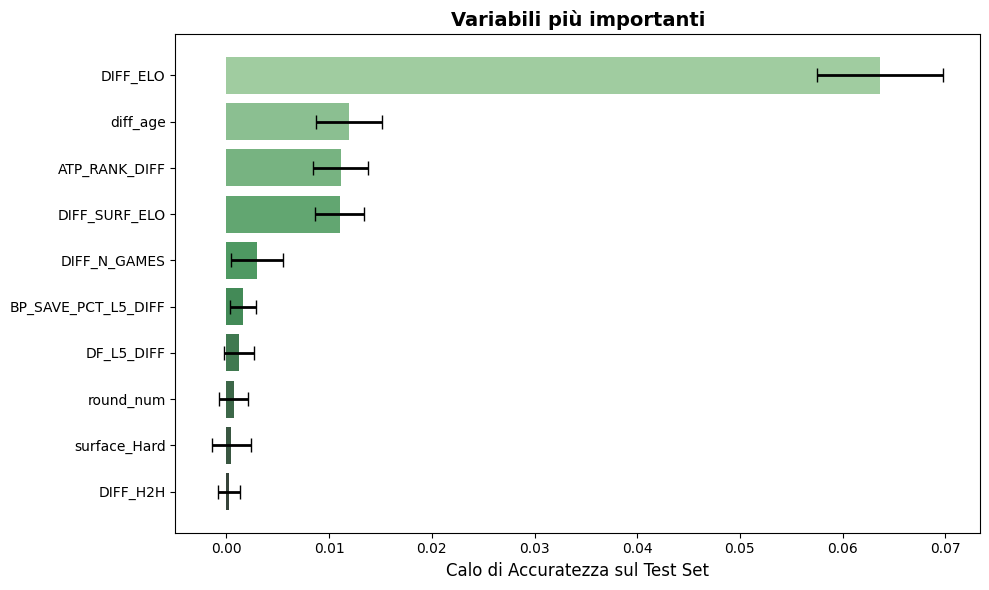

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

print("Caricamento dati per ispezione...")
dataset_path = "../data/clean/dataset_ml_ready.csv"
X_train_clean, y_train_clean, X_test_clean, y_test_clean = get_train_test_split(dataset_path)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

mlp_baseline = MLPClassifier(hidden_layer_sizes=(128, 128, 64, 32), activation='relu', 
                             alpha=0.01, max_iter=150, early_stopping=True)
mlp_baseline.fit(X_train_scaled, y_train_clean)

result = permutation_importance(mlp_baseline, X_test_scaled, y_test_clean, n_repeats=10, random_state=42, n_jobs=-1)

importanza_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importanza': result.importances_mean,
    'Deviazione': result.importances_std
}).sort_values(by='Importanza', ascending=False)

top_features = importanza_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x='Importanza', y='Feature', data=top_features, palette='Greens_d')

plt.errorbar(x=top_features['Importanza'], 
             y=np.arange(len(top_features)), 
             xerr=top_features['Deviazione'], 
             fmt='none', c='black', capsize=5, elinewidth=2)

plt.title('Variabili più importanti', fontsize=14, fontweight='bold')
plt.xlabel('Peso Decisionale (Impatto sull\'accuratezza)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

---
---
## 4. Architettura del degrado e Profilazione

Per valutare la robustezza e la capacità di generalizzazione della rete neurale e degli altri modelli, è stata sviluppata una pipeline dedicata alla perturbazione dei dati.  Questa procedura altera artificialmente il dataset introducendo anomalie controllate basate sulle dimensioni classiche della Data Quality: Accuratezza, Coerenza e Completezza, oltre all'inserimento di Rumore Gaussiano.

### 4.1 Accuratezza
L'accuratezza misura la corrispondenza tra i dati registrati e la realtà fisica o logica di riferimento. 

- Errori fisicamente impossibili: sono stati inseriti dei valori estremi nelle feature differenziali diff_ht (differenza altezza impostata ±150 cm) e diff_age (differenza di età impostata a ±80 anni). Questo test valuta la sensibilità della rete neurale rispetto a valori anomali e fuori distribuzione.
- Rumore GFaussiano (Distorsione statistica): Viene applicato del rumore bianco gaussiano ($\mu = 0$, $\sigma = 1.5 \times \text{std\_dev}$) sulla colonna DIFF_ELO. Questo simula uno scenario realistico su misuraioni imprecise, stime errate o distorsioni nei feed di dati che corrompe la metrica dominante del modello. Il test misura la capacità della rete di estrarre comunque segnale utile.


In [ ]:
def eta_altezza(X, percentage):
    """
    Introduce errori di accuratezza (outliers) nelle differenze.
    - diff_ht: inserisce differenze estreme (es. +- 150cm)
    - diff_age: inserisce differenze impossibili (es. +- 80 anni)
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    # Selezioniamo gli indici casuali
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    
    # Modifichiamo diff_ht (differenza altezza)
    X_dirty.loc[idx, 'diff_ht'] = np.random.choice([150.0, -150.0], size=n_changes)
    
    # Modifichiamo diff_age (differenza età)
    X_dirty.loc[idx, 'diff_age'] = np.random.choice([80.0, -80.0], size=n_changes)
    
    print(f"Modificati {n_changes} record per diff_ht e diff_age ({percentage*100}%).")
    return X_dirty

def rumore_gaussiano(X, percentage):
    """
    ESPERIMENTO B: Rumore Gaussiano
    Applica una distorsione statistica (Gaussian Noise) alla colonna DIFF_ELO.
    Simula stime imprecise o fluttuazioni nel calcolo della forza dei giocatori.
    """
    X_dirty = X.copy()
    n_changes = int(len(X_dirty) * percentage)
    
    if 'DIFF_ELO' in X_dirty.columns:
        idx = np.random.choice(X_dirty.index, n_changes, replace=False)
        
        # Calcoliamo la deviazione standard originale per amplificare il rumore in proporzione
        std_dev = X_dirty['DIFF_ELO'].std()
        noise = np.random.normal(loc=0.0, scale=std_dev * 1.5, size=n_changes)
        
        # Somma del rumore gaussiano ai valori reali
        X_dirty.loc[idx, 'DIFF_ELO'] += noise
        
    return X_dirty

### 4.2 Coerenza
La coerenza valuta se i dati rispettano le relazioni logiche attese nei dati del dominio del tennis. 
- Target Flipping (Inversione Logica): I dati prestazionali del match rimangono intatti, ma l'etichetta del vincitore (target) viene invertita ($0 \rightarrow 1$ e $1 \rightarrow 0$). Questo introduce una forte contraddizione logica nel dataset (input identici ma etichette opposte) e valuta la capacità della MLP di non andare in over-fitting sul rumore.
- Feature Contradiction (Incoerenza di Dominio): Viene invertito il segno della differenza di Ranking ATP (ATP_RANK_DIFF moltiplicato per $-1$), lasciando invariato il differenziale ELO. Questo crea un paradosso logico (un giocatore risulta superiore per Elo ma penalizzato dal Ranking), misurando la capacità del modello di pesare correttamente le informazioni quando entrano in palese contrasto tra loro.

In [ ]:
def sporca_coerenza_target(y, percentage):
    """
    Esperimento Target Flipping
    Simula un errore critico di coerenza logica. I dati fisici del match 
    sono corretti, ma l'etichetta del vincitore viene invertita.
    """
    y_dirty = y.copy()
    n_rows = len(y_dirty)
    n_changes = int(n_rows * percentage)
    
    # Selezione casuale dei target da invertire
    idx = np.random.choice(y_dirty.index, n_changes, replace=False)
    
    # Inversione binaria (1 diventa 0, 0 diventa 1)
    y_dirty.loc[idx] = 1 - y_dirty.loc[idx] 
    
    return y_dirty


def sporca_coerenza_elo_ranking(X, percentage):
    """
    Esperimento Feature Contradiction
    Simula un'incoerenza di dominio: inverte il segno della differenza 
    di Ranking ATP mantenendo l'Elo intatto. 
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    if 'ATP_RANK_DIFF' in X_dirty.columns:
        idx = np.random.choice(X_dirty.index, n_changes, replace=False)
        
        # Creazione del paradosso logico invertendo il segno del ranking
        X_dirty.loc[idx, 'ATP_RANK_DIFF'] = X_dirty.loc[idx, 'ATP_RANK_DIFF'] * -1
        
    return X_dirty

### 4.3 Completezza e Tempestività
La completezza misura l'impatto della carenza di informazioni sul sistema predittivo mentre la tempestività analizza l'obsolescenza causata da ritardi nei sistemi di aggiornamento
- Blackout Sistemico (Completezza): una percentuale controllata di dati viene cancellata casualmente all'interno del dataset tramite l'introduzione di valori NaN. 
- Data Staleness (Tempestività): si crea uno scenario in cui i dati di un certo numero di match scelto non siano stati inseriti, simulando ritardi nei processi di aggiornamento delle informazioni.

In [ ]:
def introduci_missing_values(X, percentage):
    """
    Simula la mancanza di dati inserendo NaN casuali.
    - percentage: percentuale di celle totali da svuotare.
    """
    X_dirty = X.copy()
    # Creiamo una maschera booleana casuale
    mask = np.random.rand(*X_dirty.shape) < percentage
    X_dirty[mask] = np.nan
    
    print(f"Svuotato il {percentage*100}% delle celle totali del dataset.")
    return X_dirty

def sporca_elo_last(X, percentage, lag=10):
    """
    Simula un ritardo nell'aggiornamento dell'Elo.
    Sostituisce il valore attuale con quello di 'lag' posizioni precedenti.
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    # Selezioniamo le colonne che contengono 'elo'
    elo_cols = [col for col in X_dirty.columns if 'elo' in col.lower()]
    
    for col in elo_cols:
        # Creiamo una serie con i valori traslati (quelli di 10 righe fa)
        # shift(lag) sposta i dati, bfill() riempie i primi 10 buchi con il primo valore disponibile
        stale_values = X_dirty[col].shift(lag).bfill()
        
        # Scegliamo gli indici da sporcare
        idx = np.random.choice(X_dirty.index, n_changes, replace=False)
        
        # Sostituiamo i valori attuali con quelli vecchi
        X_dirty.loc[idx, col] = stale_values.loc[idx]
        
    print(f"Simulato ritardo di {lag} partite per l'Elo ({percentage*100}% dei record).")
    return X_dirty


## 5. Risultati e grafici
Abbiamo simulato scenari in cui i flussi di dati presentano un degrado progressivo  ($\epsilon \in \{0\%, 5\%, 10\%, 20\%, 30\%, 50\%\}$), al fine di valutarne l'impatto sulla stabilità del modello. Per agevolare il confronto, in tutti i grafici è riportata la baseline, fissata al valore di 0,6572.

### 5.1 Accuratezza: Outliers Estremi vs Rumore Gaussiano
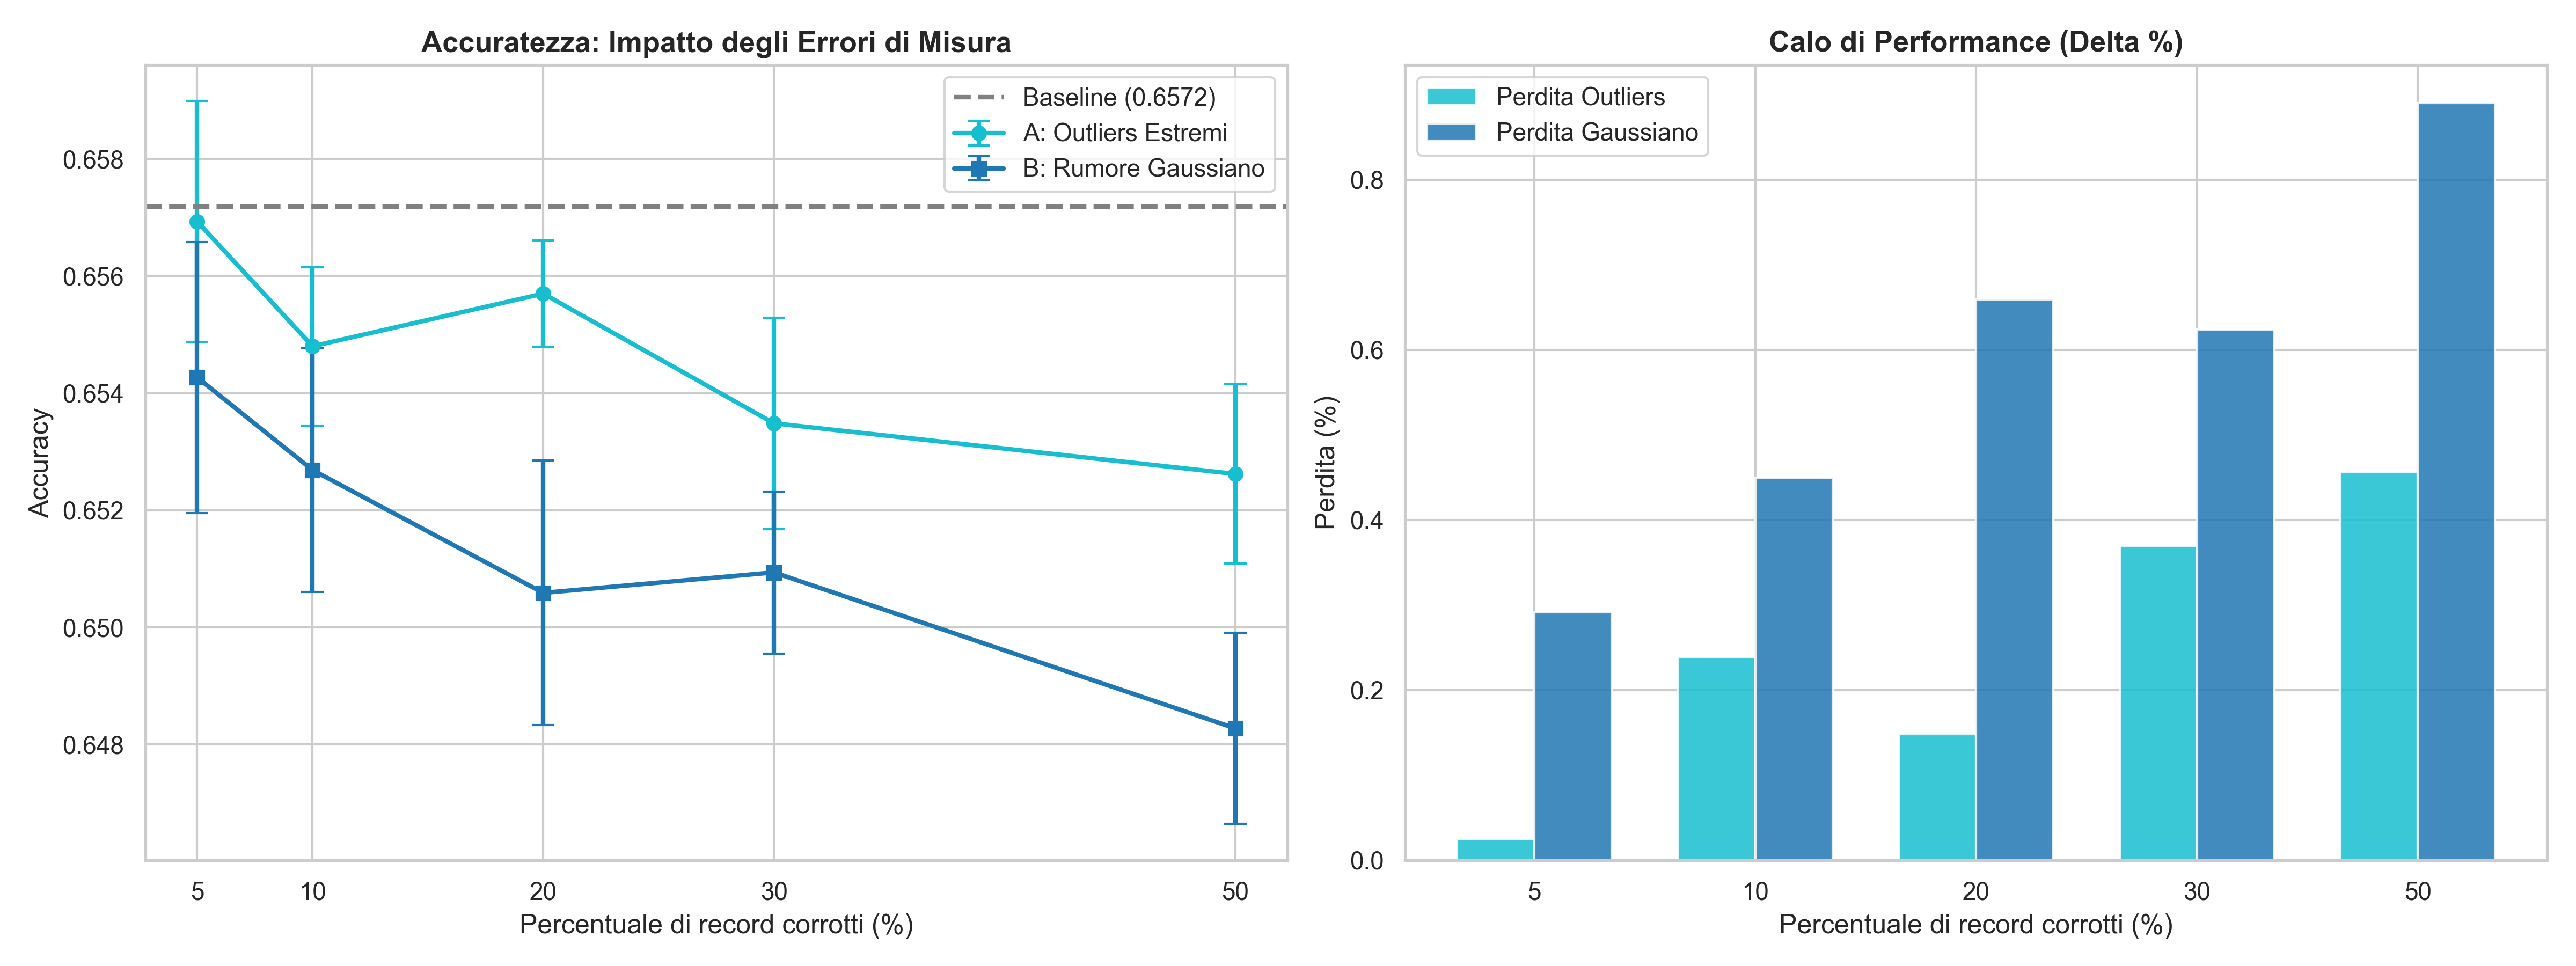

Il grafico di sinistra mostra come varia l'accuracy all'aumentare di record corrotti. 
L'accuratezza di entrambi i metodi diminuisce all'aumentare della percentuale di dati alterati. Entrambe le curve si trovano al di sotto della linea di baseline. 
Il rumore gaussiano (colore blu scuro) è stabilmente più bassa della linea degli ouliers estremi (colore azzurro). Ciò significa che l'introduzione di un rumore distribuito in modo gaussiano danneggia l'accuratezza del modello molto di più rispetto alla presenza di outliers, a parità di record degradati.

Il grafico di destra quantifica la perdita di performance rispetto alla baseline originaria. 
La perdita dovuta al rumore gaussiano cresce in modo costante con l'aumentare dei record corrotti, mentre quella dovuta agli outliers estremi mostra un calo al 20% per poi riprendere a salire fino a circo al 45%, (coerente con la risalita nel grafico di sinistra).
Al massimo livello di corruzione, l'impatto del rumore gaussiano sul calo di performance è circa di doppio rispetto a quello degli outliers estremi.

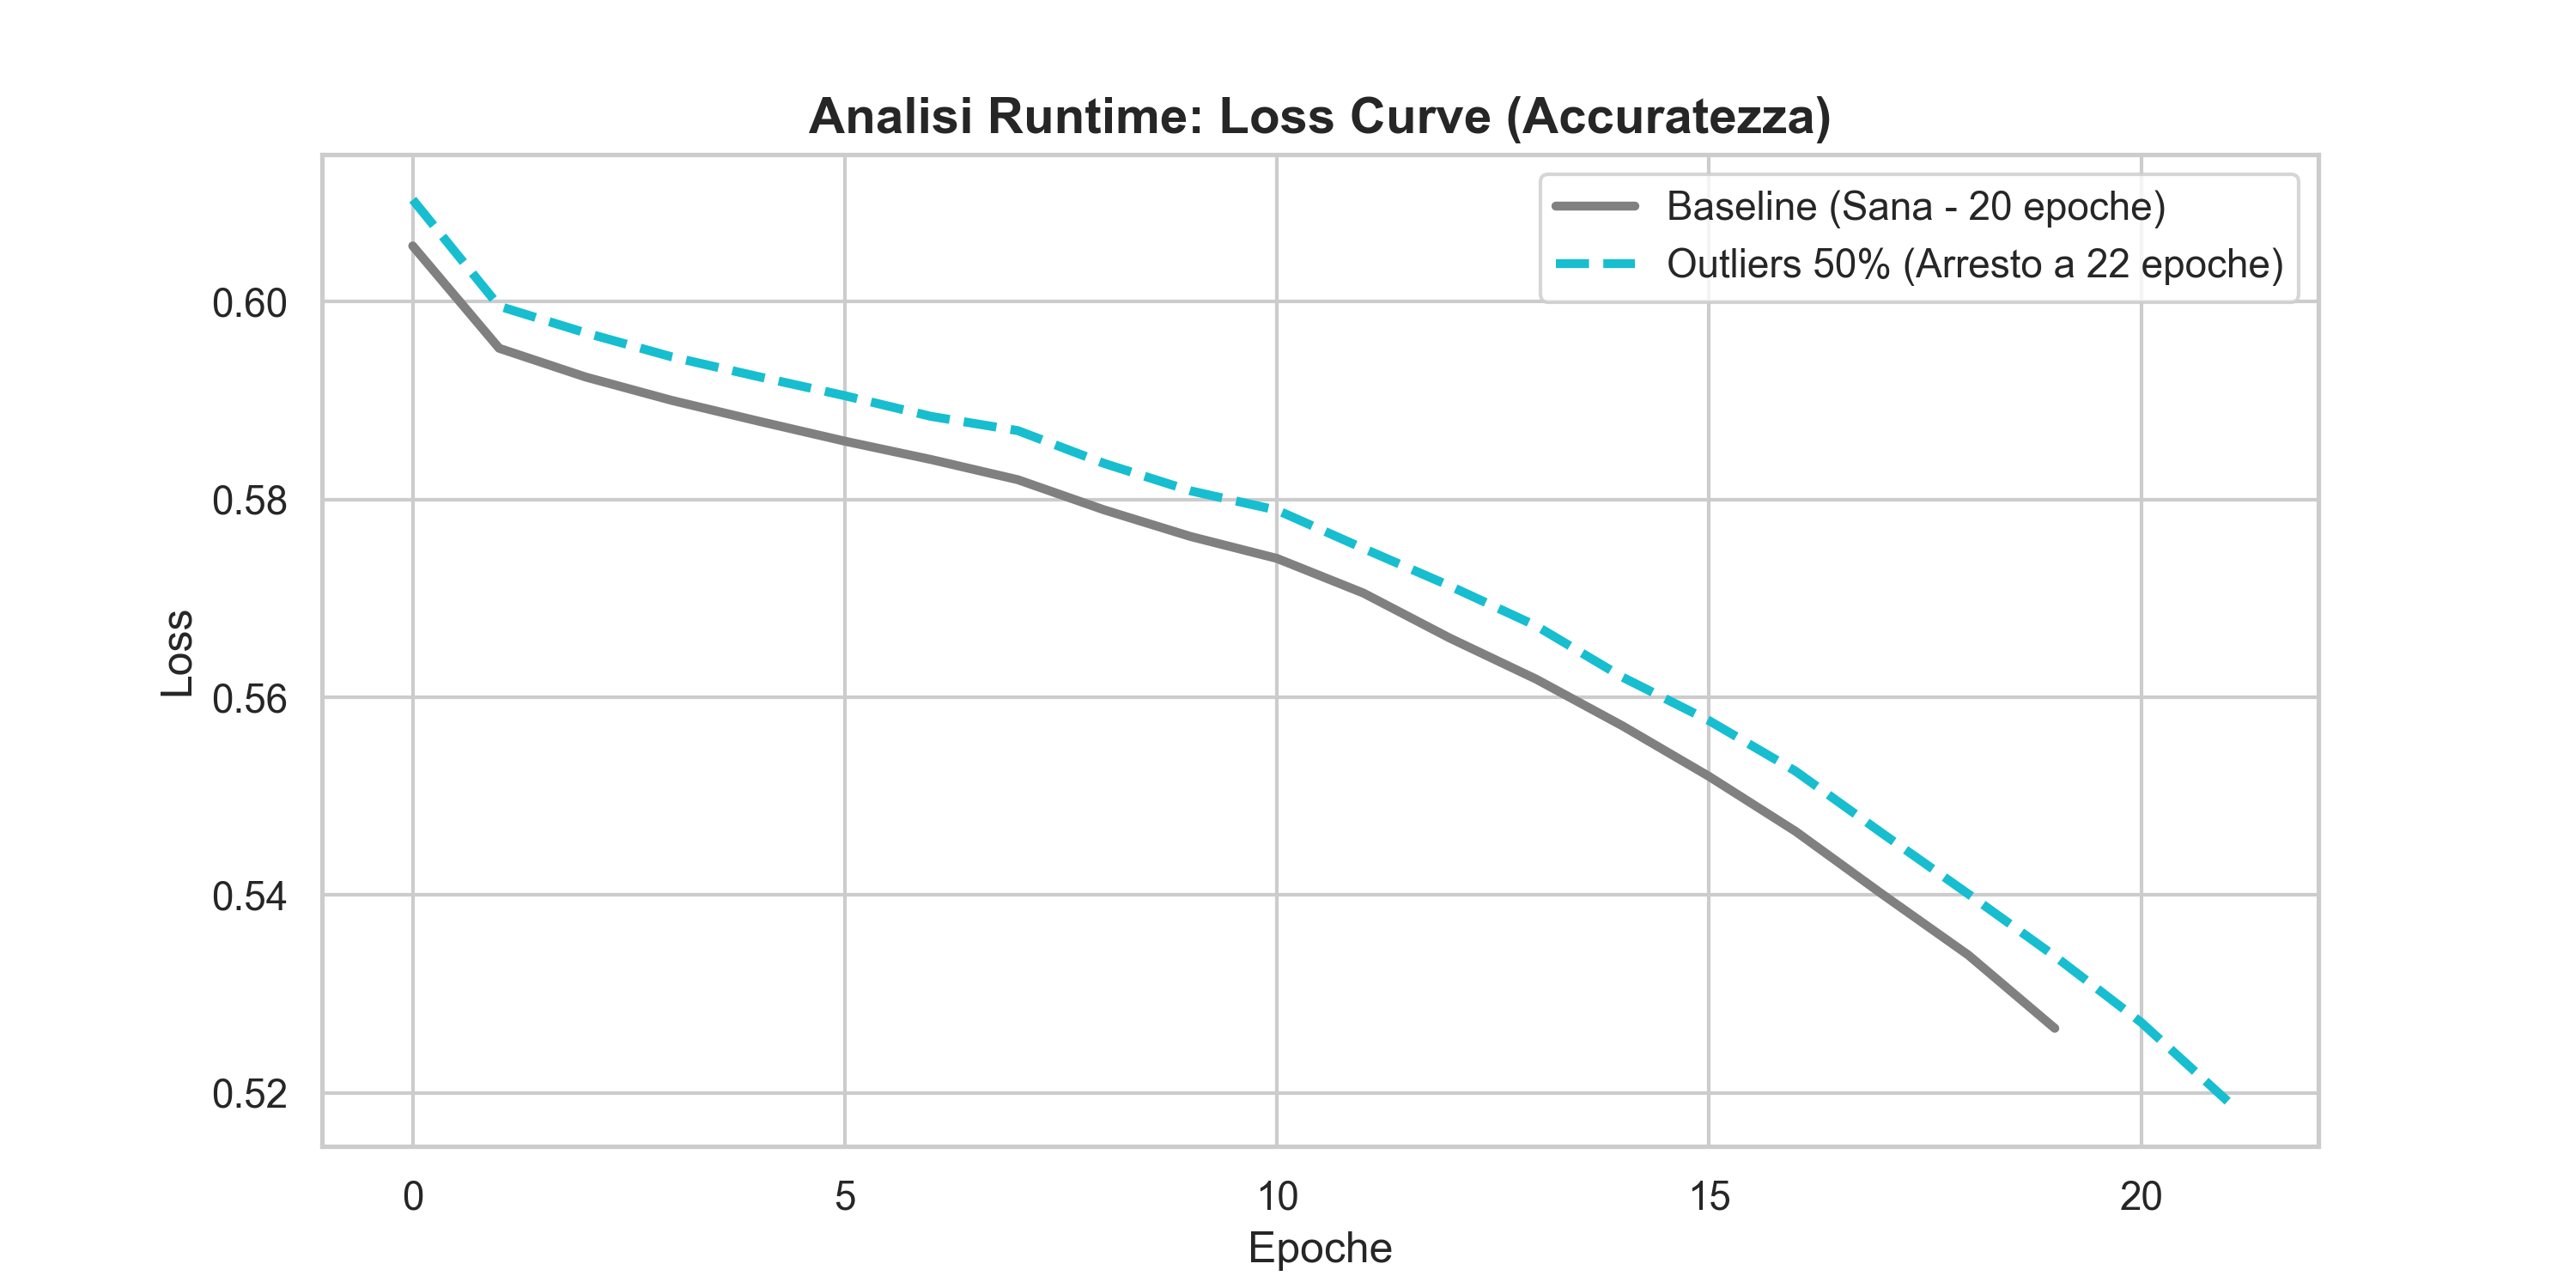

Questo grafico mostra l'andamento della Loss (funzione di perdita) durante l'addestramento di un modello lungo varie epoche, mettendo a confronto la Baseline e la situazione con il 50% di outliers.
Per entrambe le curve, la loss descresce in modo costante all'aumentare delle epoche. Questo indica che il modello sta effettivamente imparando e ottimizzando i parametri in entrambi gli scenari, senza mostrare evidenti segni di blocco o divergenza. 
Baseline (sana) arriva a concludere l'addestramento in 20 epoche. 
L'addestramento per Outliers 50% si prolunga leggermente fino a 22 epoche e infine raggiungere il valore di loss vicino al 0.520. 


### 5.2 Completezza: 
## Impatto dati mancanti
In questi grafici confronteremo diverse strategie di sostituzione dei valori mancanti: mean imputation (arancione, media della colonna), zero default (marrone, azzeramento di tutti i valori).

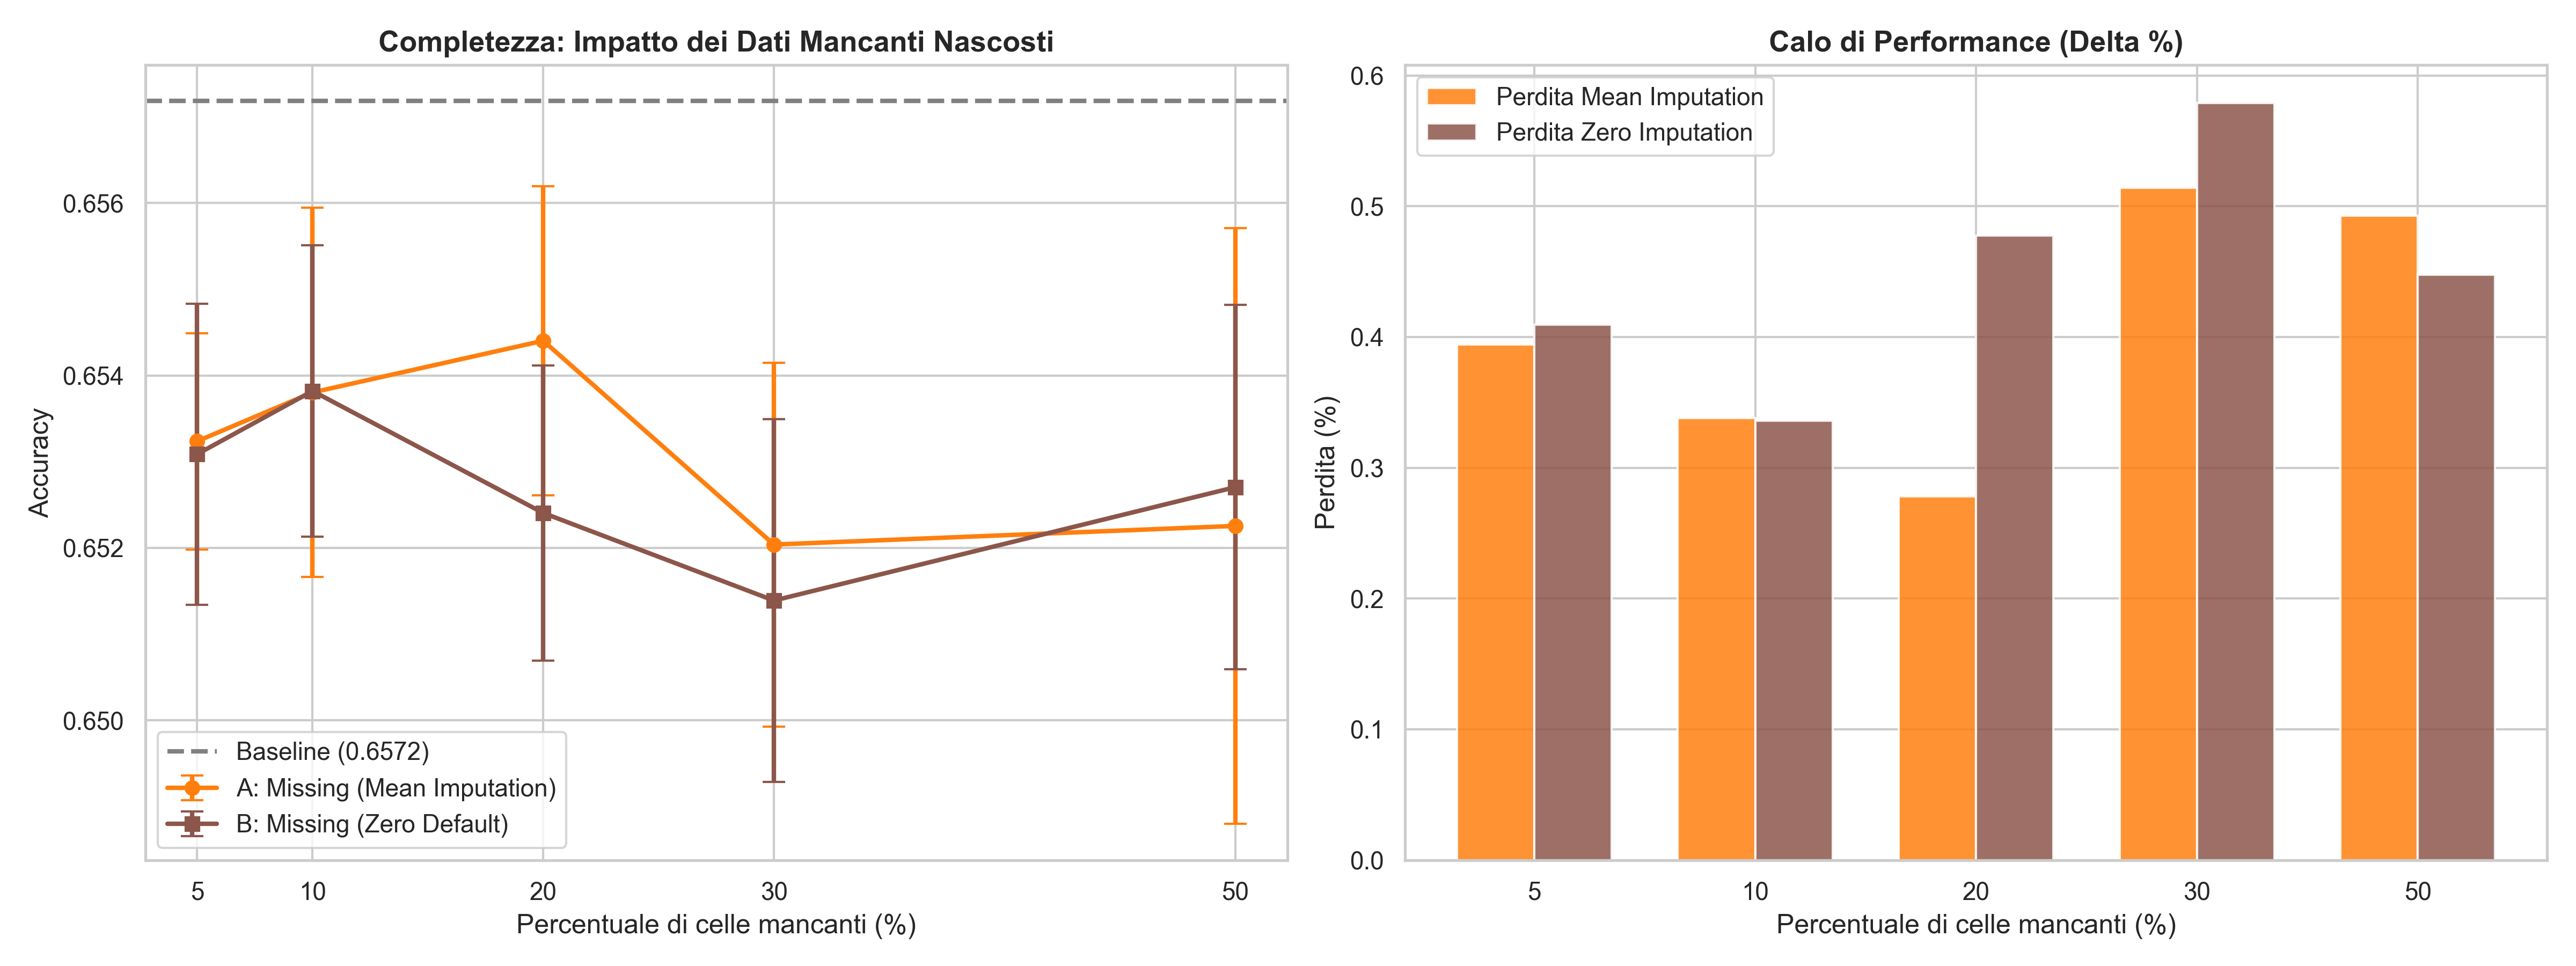

Dal grafico di sinistra si evince che l'impatto dei dati mancanti è più contenuto, in quanto l'accuratezza rimane in un intevallo abbastanza ristretto <0.651; 0.654>. 
Le curve non mostrano un crollo verticale continuo all'aumentare delle celle mancanti. Inoltre e barre d'errore sono molto estese e si sovrappongono quasi completamente per tutta l'estensione del grafico, quindi possiamo dedurre che dal punto di vista statistico la differenza tra le due tecniche non è netta. 

Nel grafico di destra viene quantificata la percentuale di accuratezza persa rispetto alla baseline. 
Coerente al grafico precedente la perdita massima registrata non arriva nemmeno al 0.6%. 
Fino al 10% l'impatto delle due tecniche è praticamente identico. 
Al 20% e al 30% la colona della zero default è visibilmente più alta di quella arancione: questo significa che in questa fascia modificare i dati con la media preserva meglio le performance del modello. 
Al 50% la situazione si ribalta leggermente. Quando la metà dei dati è mancante, sostituire tutto con la media probabilmente "appiattisce" eccessivamente la variabilità delle features. 

## Blackout Elo vs Lag 25 partite

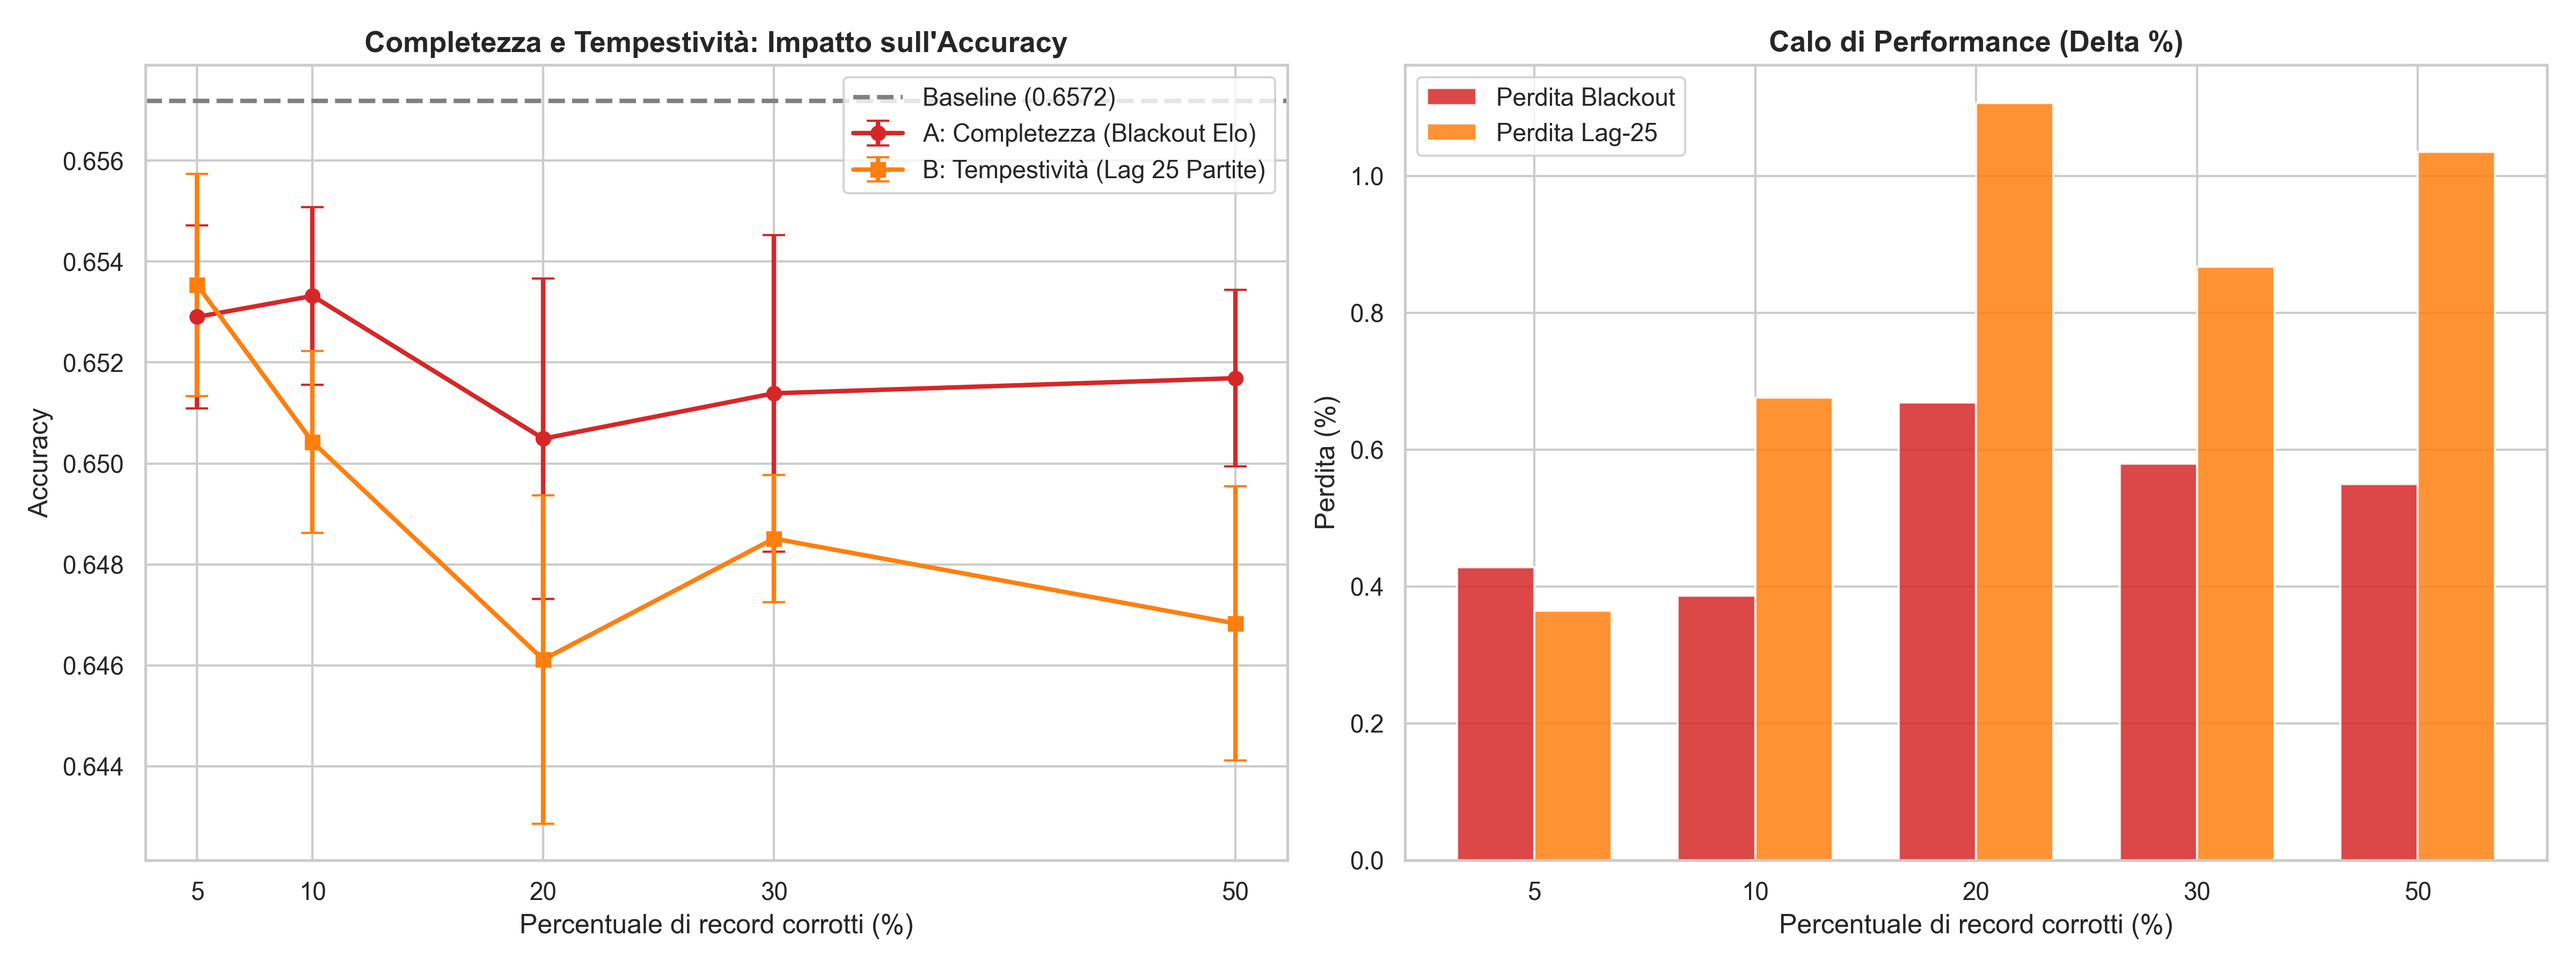

In questi grafici mettiamo a confronto la completezza e la tempestività. 

Dal grafico di sinistra si nota che la tempestività è più critica della completezza, essendo la linea arancione sempre stabilmente al di sotto della rossa. Ciò significa che un ritardo nell'aggiornamento dei dati danneggia l'accuratezza del modello in modo più marcato rispetto alla mancanza di dati. 

Il grafico a barre mostra che il blackout ha una stabilità del danno, in quanto una volta superato il 5% la sua perdita rimane nella fascia <0.4; 0.65>. Al contrario dal 10% il Lag si stacca nettamente dal blackout generando costantemente perdite superiori.


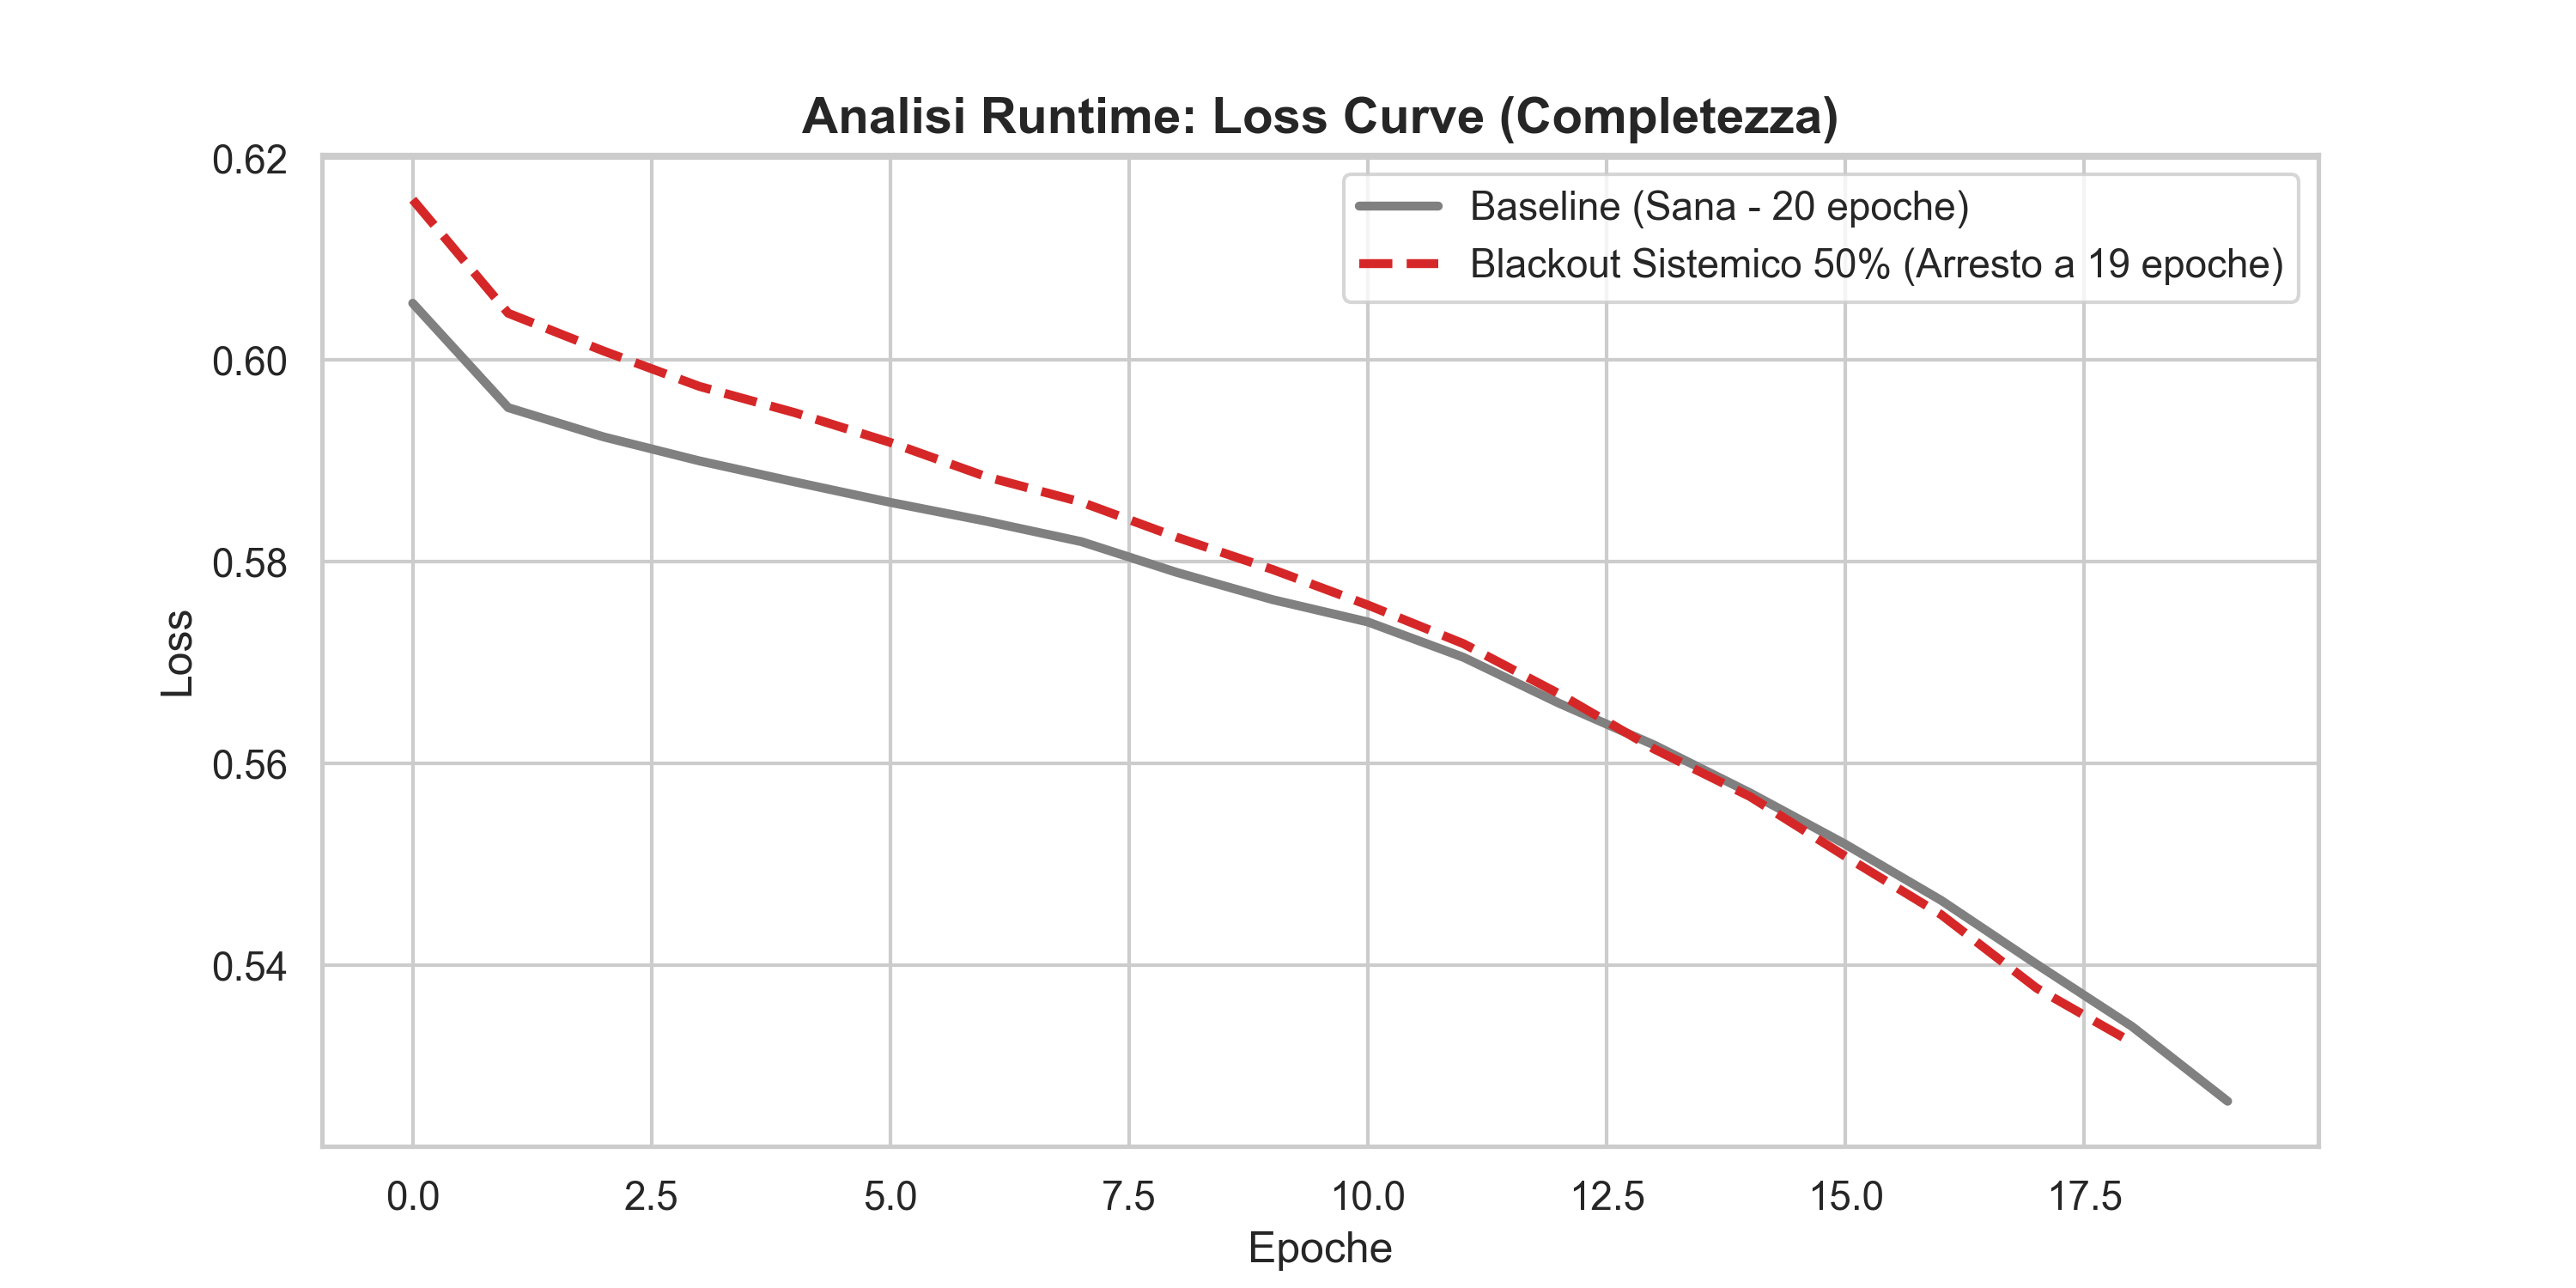

Notiamo che nella prima 10 epoche la linea del blackout si trova sopra la baseline. Questo indica che all'inizio dell'addestramento, la mancanza dei dati storici rende il compito più difficile. Avendo meno informazioni, la funzione di perdita è più alta.

Intorno all'epoca 12.5 la curva rossa interseca la grigia e la loss del blackout diventa leggermente inferiore rispetto alla baseline. 
Quando a un modello viene tolto il 50% dei dati, il dataset di addestramento diventa più piccolo e semplificato, quindi costringe la rete a convergere molto rapidamente, arrestandosi a 19 epoche contro le 20 della baseline(sana). 


## 5.3 Coerenza dei dati
## Confronto tra Target Flipping e incoerenza Elo-Ranking 
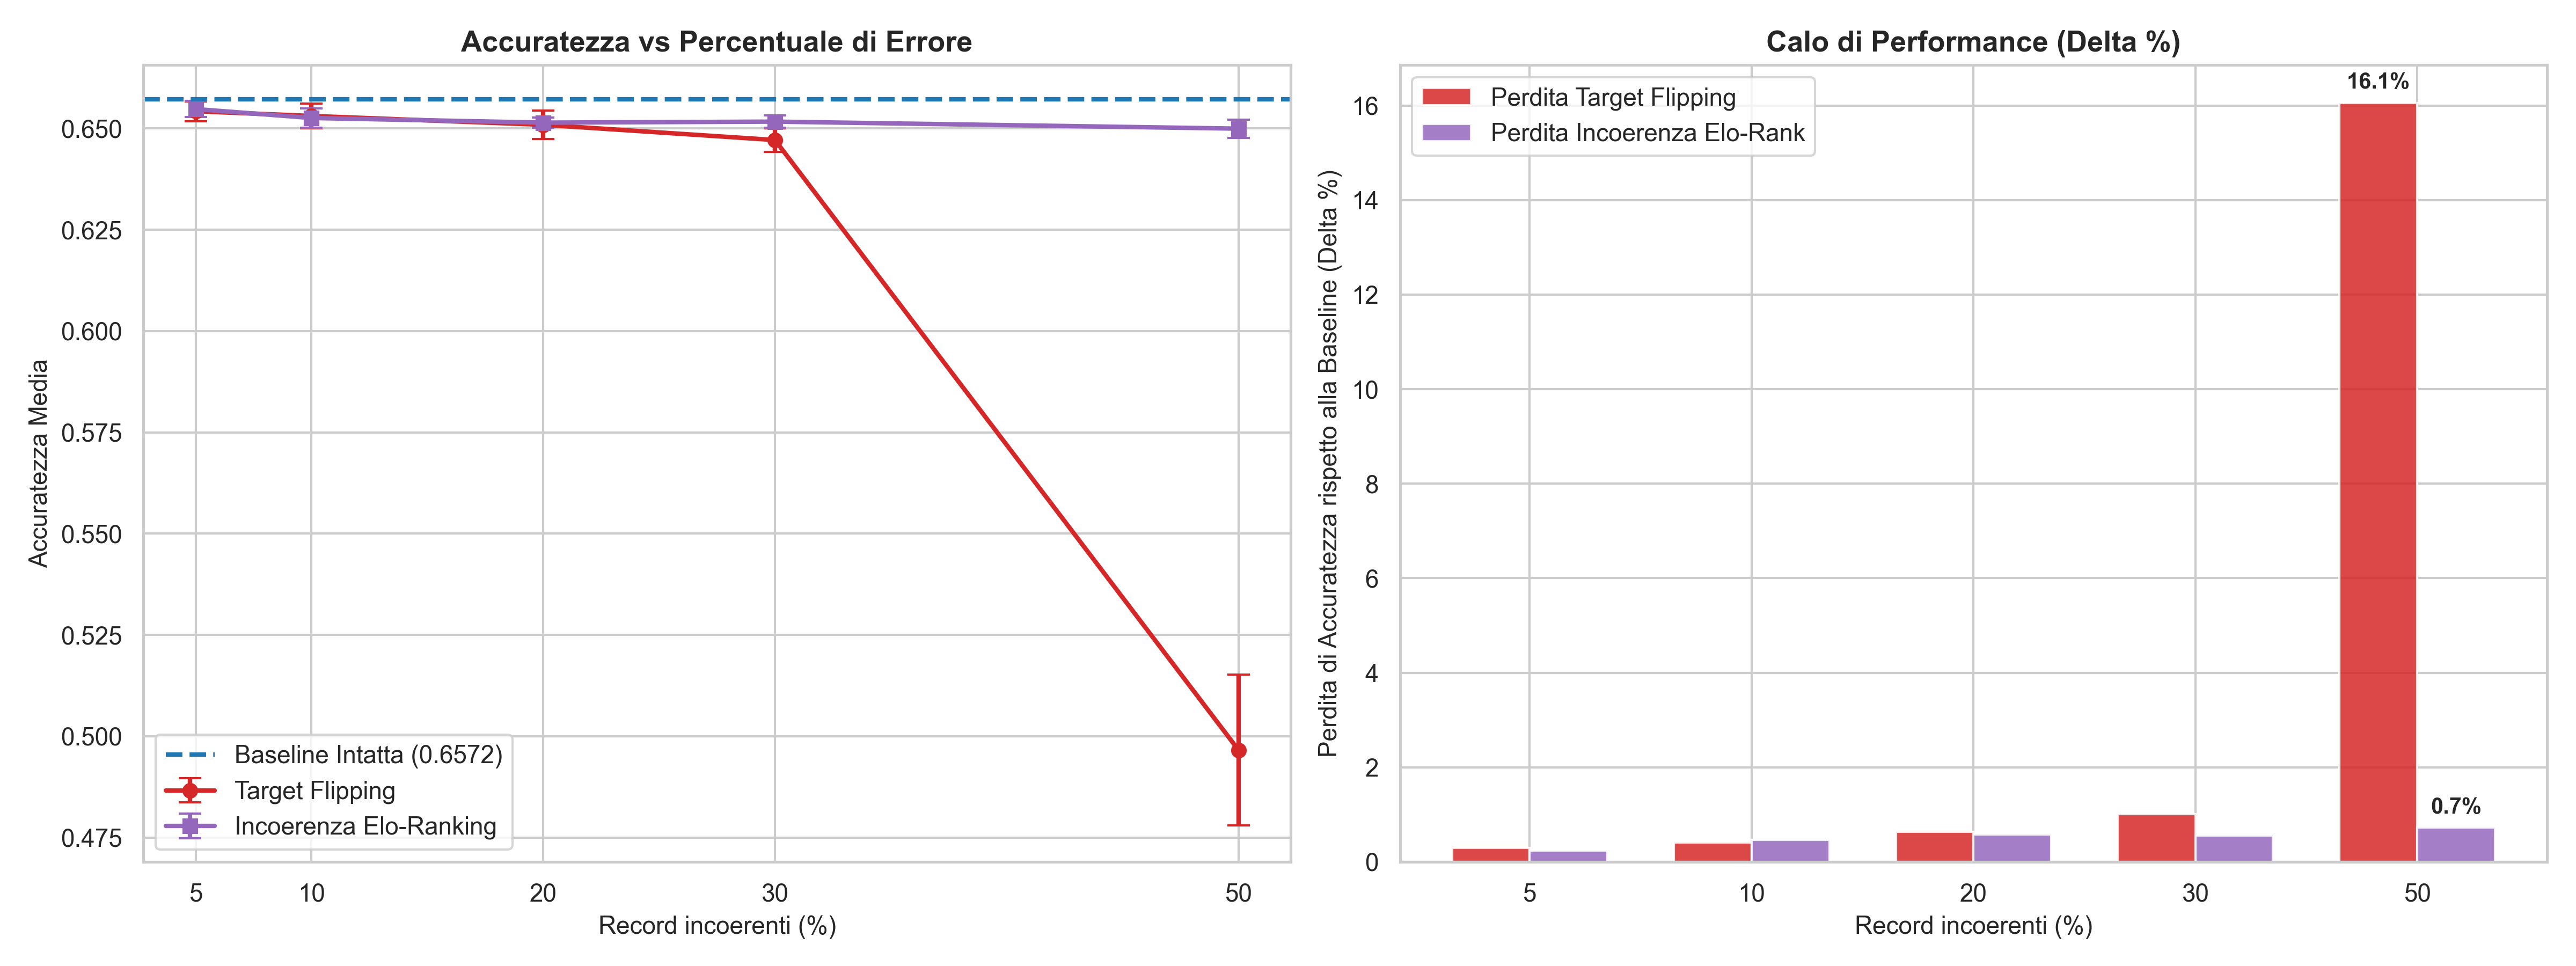

Il grafico a sinistra analizza come si comporta l'accuratezza media quando inseriamo una percentuale crescente di dati incoerenti o errati. 
Fino a quando la corruzione dei dati rimane entro il 30%, il modello mostra una notevole resistenza. Quando si raggiunge il 50% di dati corrotti il target flipping subisce un crollo significativo, toccando il valore di accuratezza vicino al 0.496.

Il grafico a barre conferma quando visto nel primo grafico. Fino al 30% le perdite di entrambi i metodi sono sotto 1%, al 50% la barra rossa si impenna registrando un calo del 16,1% di accuratezza. 

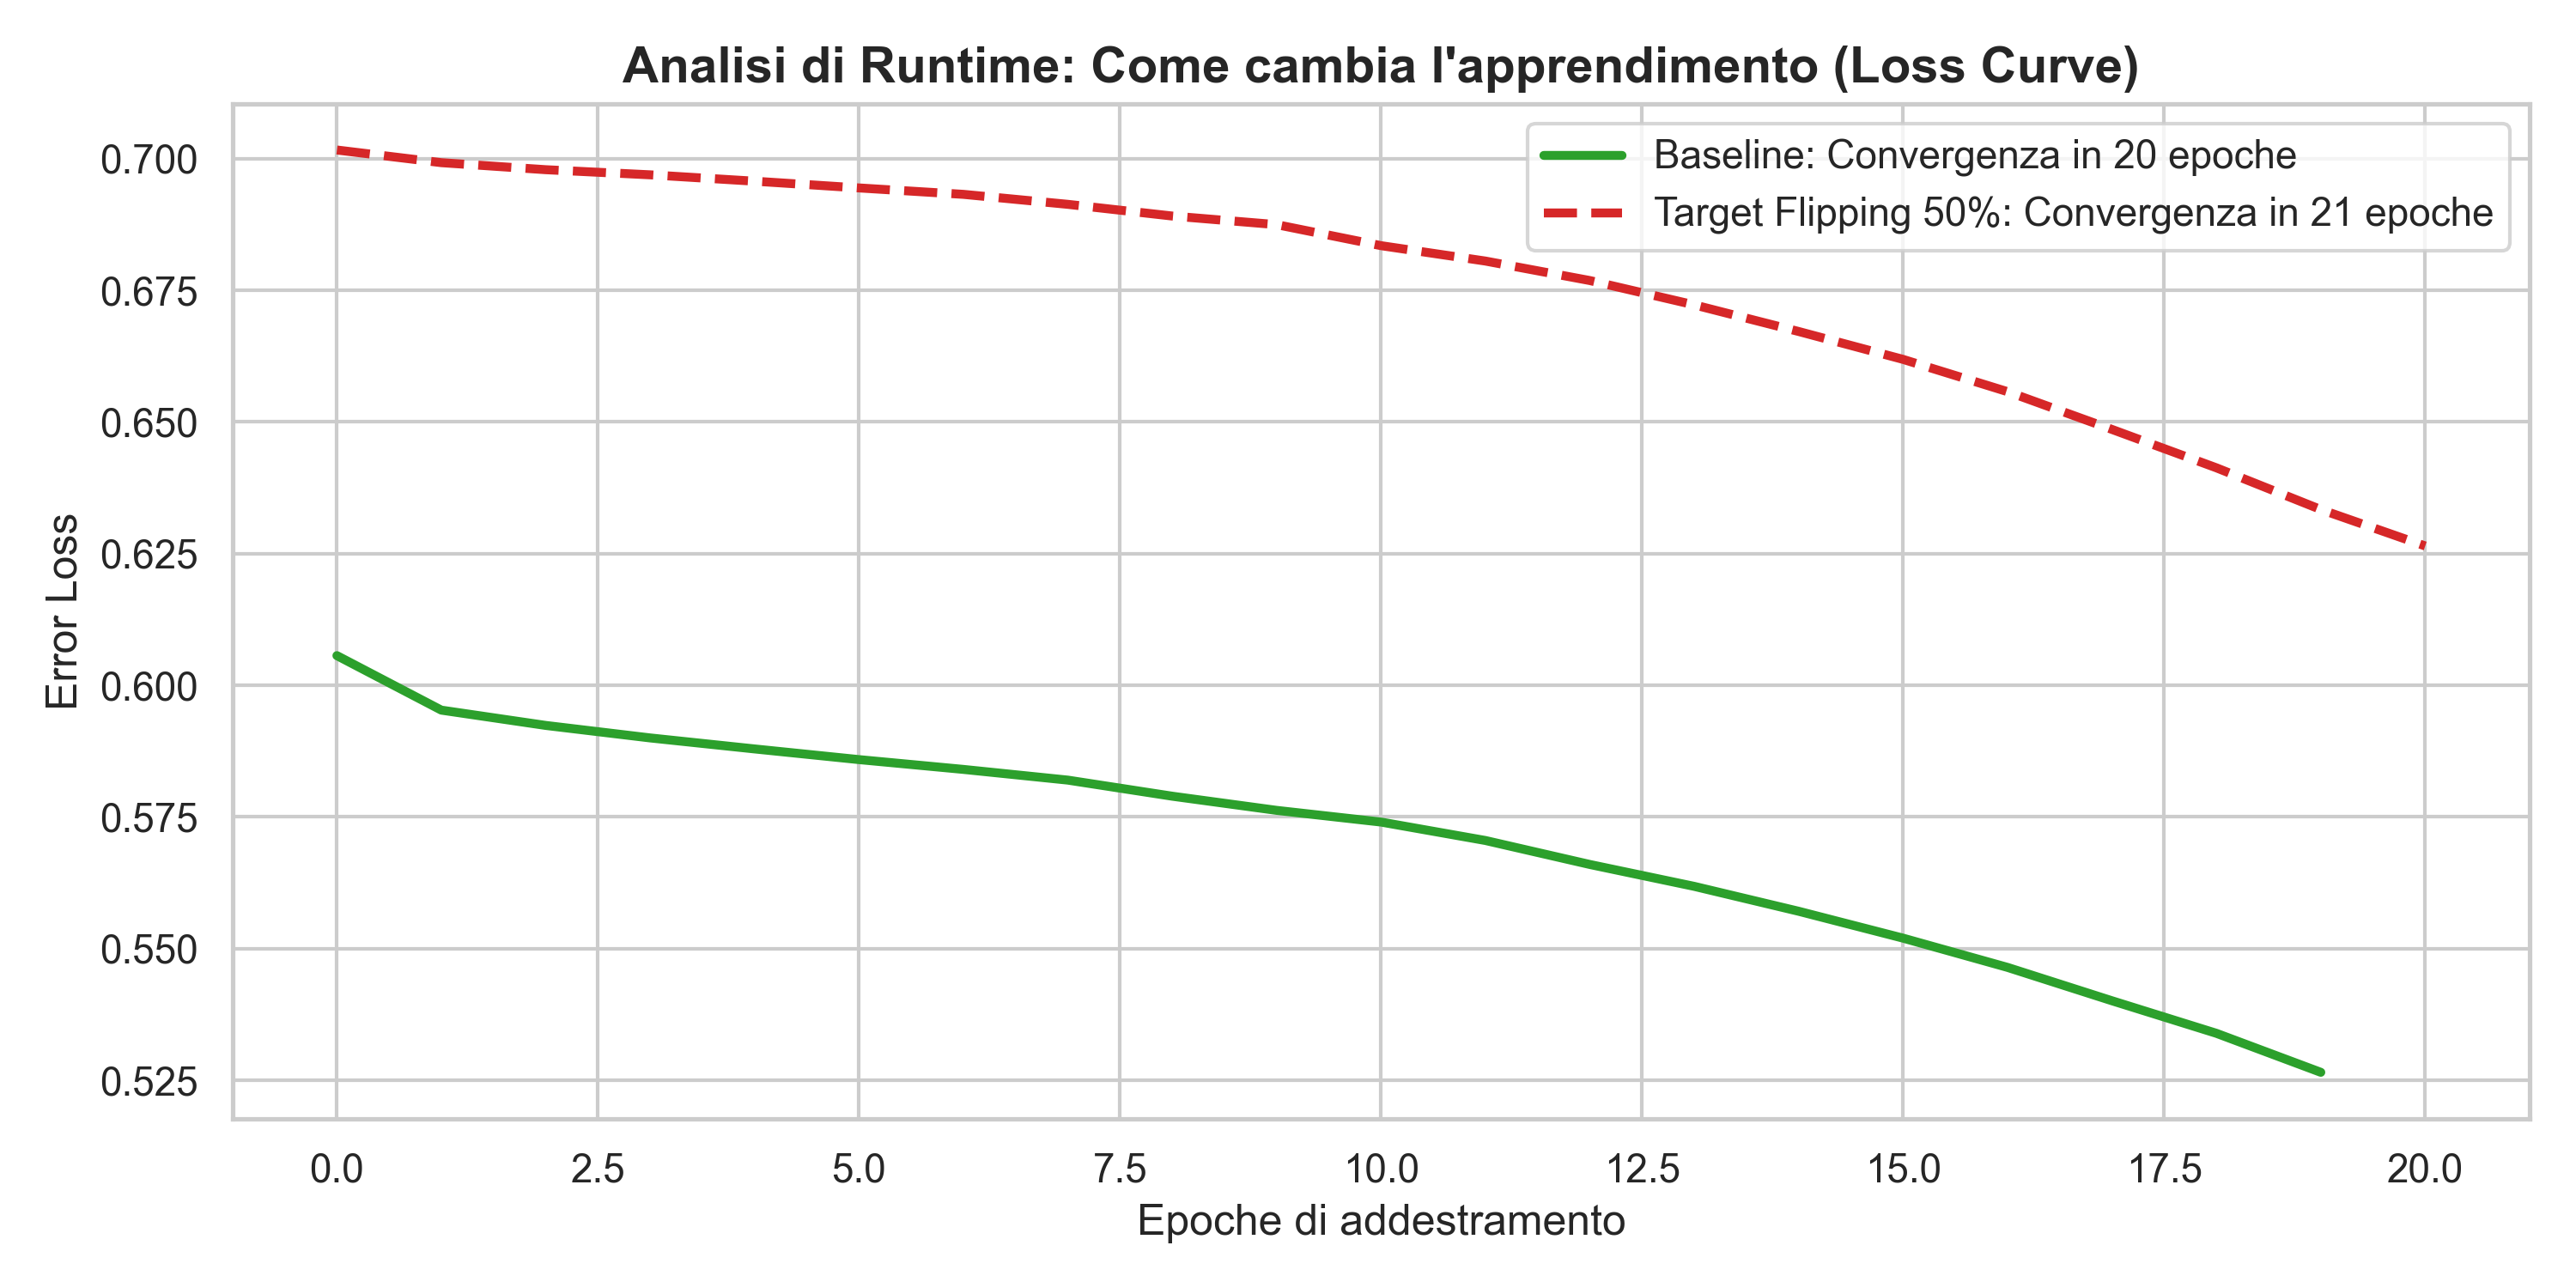

In questo grafico si nota subito che il target flipping mantiene una distanza notevole dalla baseline. Il modello continua a ricevere dati contraddittori e non riesce a trovare una logica.
Osservando la pendenza della curva, si nota che la rete non riesce a imparare, ma sta solo cercando di minimizzare l'errore. 
Si arresta intorno alle 21 epoche, non perchè abbia trovato una soluziona, ma perchè ha esaurito i tentativi utili.